<a href="https://colab.research.google.com/github/Rageel-28/244107020136-Machine-Learning/blob/main/JS03/JS03_Tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Lab - JS03: Ekstraksi & Seleksi Fitur
## Wisconsin Breast Cancer (Again)

**Nama:** Rakagali Resda Krisandi Putra
**Mata Kuliah:** Pembelajaran Mesin (RTI235004)
**Referensi modul:** JS03 - Ekstraksi Fitur (Lab 1: Ekstraksi Fitur Pada Data Tabular)




## Langkah 1 - Import Library


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay


## Langkah 2 - Load Data dan Pemisahan Variabel (Poin 1)

Dataset "Wisconsin Breast Cancer" (`data.csv`) berisi 569 baris data dengan kolom:

- `id` -> **tidak dapat digunakan**, hanya nomor identitas pasien, tidak punya nilai prediktif.
- `Unnamed: 32` -> **tidak dapat digunakan**, kolom kosong (artefak export CSV), seluruh isinya `NaN`.
- `diagnosis` -> **variabel target (y)**, berisi label `M` (Malignant) atau `B` (Benign).
- 30 kolom sisanya (`radius_mean`, `texture_mean`, ..., `fractal_dimension_worst`) -> **variabel fitur (X)** yang dapat digunakan, seluruhnya bertipe numerik.

In [ ]:
# Load Data
df = pd.read_csv("data.csv")
print("Shape awal:", df.shape)
df.head()


Shape awal: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842303,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,842304,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,842305,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,842306,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
# Cek kolom yang tidak relevan
print(df.isna().sum()[df.isna().sum() > 0])  # 'Unnamed: 32' seharusnya 100% NaN
print(df["id"].nunique(), "nilai unik pada kolom id ->", "sama dengan jumlah baris" if df["id"].nunique()==len(df) else "tidak unik")


Unnamed: 32    569
dtype: int64
569 nilai unik pada kolom id -> sama dengan jumlah baris


In [ ]:
# Buang kolom yang tidak dapat digunakan
df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")

# Pisahkan target dan fitur
y_raw = df["diagnosis"]
X = df.drop(columns=["diagnosis"])

# Seluruh kolom yang tersisa pada X adalah kolom numerik
num_cols = X.columns.tolist()
print("Jumlah fitur yang dapat digunakan:", len(num_cols))
print(num_cols)


Jumlah fitur yang dapat digunakan: 30
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


## Langkah 3 - Encoding Kolom `diagnosis` (Poin 2)

Kolom `diagnosis` berisi label kategorikal (`M`/`B`). Karena kasusnya adalah klasifikasi biner, kita gunakan `LabelEncoder` untuk mengubahnya menjadi numerik (0/1).

In [ ]:
le = LabelEncoder()
y = le.fit_transform(y_raw)

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Mapping hasil encoding:", mapping)
# {'B': 0, 'M': 1} -> Benign = 0, Malignant = 1


Mapping hasil encoding: {'B': np.int64(0), 'M': np.int64(1)}


## Langkah 4 - Standardisasi Kolom Numerik (Poin 3)

Karena seluruh 30 fitur bertipe numerik dan memiliki skala yang jauh berbeda (misal `area_mean` bernilai ratusan-ribuan sedangkan `smoothness_mean` bernilai desimal kecil), kita standardisasi menggunakan `StandardScaler` yang dibungkus dalam `Pipeline`, kemudian disatukan lewat `ColumnTransformer`

In [ ]:
# Ekstraksi fitur (standardisasi) dengan Pipeline
num_tf = Pipeline([
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer([
    ("num", num_tf, num_cols)
])


## Langkah 5 - Seleksi Fitur dengan SelectKBest (Poin 4)

Karena seluruh fitur numerik dan target kategorikal biner, kita gunakan `f_classif` (uji ANOVA) sebagai `score_func` pada `SelectKBest`


In [ ]:
selector_filter = SelectKBest(score_func=f_classif, k=10)  # k awal, akan dioptimasi di Langkah 7


## Langkah 6 - Pipeline Final & Pengujian dengan Logistic Regression (Poin 5 & 6)

Seluruh proses (standardisasi -> seleksi fitur -> model) digabungkan dalam satu `Pipeline` agar mudah dipakai ulang dan terhindar dari *data leakage* saat `train_test_split`.

In [ ]:
pipe_filter = Pipeline([
    ("prep", preprocess),          # standardisasi
    ("sel", selector_filter),      # seleksi fitur SelectKBest
    ("clf", LogisticRegression(max_iter=5000))  # model uji
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

pipe_filter.fit(X_train, y_train)
pred = pipe_filter.predict(X_test)

print("=== SelectKBest (k=10, ANOVA) + Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred, target_names=le.classes_))


=== SelectKBest (k=10, ANOVA) + Logistic Regression ===
Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           B       0.95      0.99      0.97        72
           M       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## Langkah 7 - Mencari Jumlah Fitur (k) Terbaik (Poin 7)

Nilai `k=10` di atas hanya contoh awal. Untuk menjawab **"berapa jumlah fitur terbaik"**, kita perlu mencoba beberapa nilai `k` (dari 1 sampai 30 fitur) dan membandingkan performanya menggunakan **cross-validation pada data latih** (bukan data uji, agar hasil pemilihan `k` tidak bocor/overfit ke data tes).

In [ ]:
k_range = range(1, len(num_cols) + 1)
cv_scores = []

for k in k_range:
    pipe = Pipeline([
        ("prep", preprocess),
        ("sel", SelectKBest(score_func=f_classif, k=k)),
        ("clf", LogisticRegression(max_iter=5000))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

hasil_k = pd.DataFrame({"k": list(k_range), "cv_accuracy": cv_scores})
hasil_k.sort_values("cv_accuracy", ascending=False).head(10)


,k,cv_accuracy
25,26,0.973626
24,25,0.973626
23,24,0.973626
18,19,0.973626
21,22,0.973626
20,21,0.973626
19,20,0.971429
22,23,0.971429
27,28,0.971429
26,27,0.971429


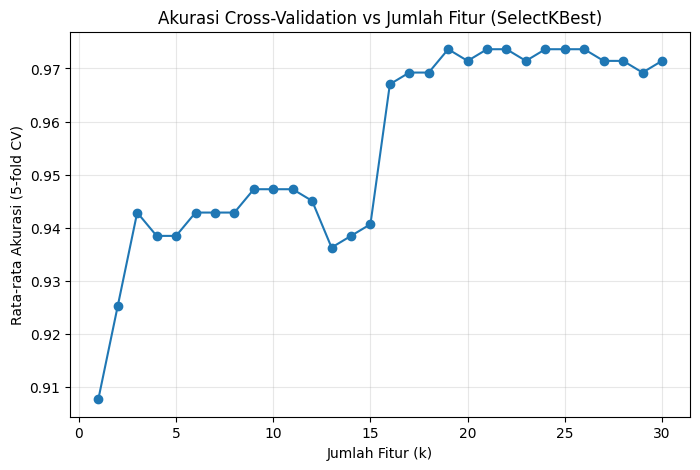

k dengan akurasi CV tertinggi: 19 | akurasi CV: 0.9736263736263737


In [ ]:
plt.figure(figsize=(8,5))
plt.plot(hasil_k["k"], hasil_k["cv_accuracy"], marker="o")
plt.xlabel("Jumlah Fitur (k)")
plt.ylabel("Rata-rata Akurasi (5-fold CV)")
plt.title("Akurasi Cross-Validation vs Jumlah Fitur (SelectKBest)")
plt.grid(True, alpha=0.3)
plt.show()

best_k = int(hasil_k.loc[hasil_k["cv_accuracy"].idxmax(), "k"])
print("k dengan akurasi CV tertinggi:", best_k, "| akurasi CV:", hasil_k["cv_accuracy"].max())


### Interpretasi Grafik

Dari hasil di atas terlihat pola umum seleksi fitur:

- Akurasi CV naik cukup cepat pada `k` kecil (1-9), lalu **relatif stabil/naik landai** setelah `k` sekitar 9-11.
- Ada lonjakan lagi pada `k` sekitar 16 ke atas, lalu **grafik menjadi datar (plateau)** mulai `k` sekitar 19-30 dengan akurasi CV tertinggi (selisih antar-k pada rentang ini sangat kecil, dalam orde <0.5%).

Karena akurasi pada `k` besar (19-30) hanya berbeda tipis dengan `k` yang lebih kecil (mis. `k=10`), **prinsip parsimoni (model paling sederhana dengan performa yang sudah "cukup baik")** relevan untuk dipertimbangkan: menambah fitur lebih banyak dari titik plateau tidak memberikan keuntungan akurasi yang signifikan, namun membuat model lebih kompleks dan lebih rawan overfitting pada data yang lebih variatif.

Kita akan mengevaluasi dua kandidat: `k` dengan akurasi CV tertinggi (hasil pencarian otomatis di atas), dan `k=10` sebagai model yang lebih ringkas.

In [ ]:
for k in sorted(set([10, best_k])):
    pipe = Pipeline([
        ("prep", preprocess),
        ("sel", SelectKBest(score_func=f_classif, k=k)),
        ("clf", LogisticRegression(max_iter=5000))
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, pred)

    feat_names = pipe.named_steps["prep"].get_feature_names_out()
    sel = pipe.named_steps["sel"]
    mask = sel.get_support()
    selected = sorted(zip(feat_names[mask], sel.scores_[mask]), key=lambda t: t[1], reverse=True)

    print(f"\n=== k={k} | Test Accuracy={acc:.4f} ===")
    print(classification_report(y_test, pred, target_names=le.classes_))
    print("Fitur terpilih (urut skor ANOVA tertinggi):")
    for name, score in selected:
        print(f"  {name.replace('num__',''):28s} skor={score:8.2f}")



=== k=10 | Test Accuracy=0.9561 ===
              precision    recall  f1-score   support

           B       0.95      0.99      0.97        72
           M       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Fitur terpilih (urut skor ANOVA tertinggi):
  concave points_worst         skor=  733.72
  perimeter_worst              skor=  717.25
  radius_worst                 skor=  692.86
  concave points_mean          skor=  684.53
  perimeter_mean               skor=  548.41
  area_worst                   skor=  522.19
  radius_mean                  skor=  511.27
  area_mean                    skor=  444.86
  concavity_mean               skor=  397.59
  concavity_worst              skor=  319.51

=== k=19 | Test Accuracy=0.9825 ===
              precision    recall  f1-score   support

           B       0.97      1.00      0.99       

## Kesimpulan (Jawaban Poin 7)

Berdasarkan hasil analisis cross-validation di atas:

- **Jumlah fitur terbaik (akurasi CV tertinggi):** hasil pencarian menunjukkan performa terus meningkat hingga mencapai titik jenuh (plateau) di sekitar **k=19** fitur dengan akurasi CV ≈ **97.4%**, dan pada data uji mencapai akurasi ≈ **98.3%**. Fitur-fitur dengan skor ANOVA tertinggi pada titik ini adalah 10 fitur teratas berikut, ditambah 9 fitur pendukung lain:
  1. `concave points_worst`
  2. `perimeter_worst`
  3. `radius_worst`
  4. `concave points_mean`
  5. `perimeter_mean`
  6. `area_worst`
  7. `radius_mean`
  8. `area_mean`
  9. `concavity_mean`
  10. `concavity_worst`

- **Alternatif model lebih ringkas (k=10):** hanya menggunakan 10 fitur di atas saja sudah menghasilkan akurasi uji ≈ **95.6%** — turun tipis (~2-3%) dibanding memakai 19 fitur, tetapi jauh lebih sederhana dan lebih cepat dihitung.

fitur-fitur dengan skor tertinggi didominasi oleh kelompok `_worst` dan `_mean` yang berkaitan dengan ukuran/bentuk sel (`radius`, `perimeter`, `area`, `concave points`, `concavity`) — secara medis masuk akal karena sel kanker (Malignant) cenderung berukuran lebih besar dan bentuknya lebih tidak beraturan (nilai *concavity*/*concave points* lebih tinggi) dibanding sel jinak (Benign). Fitur kelompok `_se` (standard error) umumnya memiliki skor ANOVA paling rendah dan baru masuk pada `k` yang lebih besar.


